# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

El accidente cerebrovascular (ACV) es una de las principales causas de muerte y discapacidad, y sus factores de riesgo más importantes (edad, hipertensión, enfermedad cardíaca) son conocidos y medibles (Boehme et al., 2017). Queremos estimar la **probabilidad de que un paciente sufra un ACV** a partir de datos clínicos básicos.

Es un problema de **clasificación binaria supervisada muy desbalanceada**: solo cerca del 5 % de los pacientes tuvo un ACV. Un clasificador que siempre responde "no" acierta el 95 % y no detecta a nadie, así que la exactitud no sirve y hay que evaluar con el AUC, la curva de precisión y recall, la calibración y el recall de la clase positiva.

**Este modelo estima un riesgo estadístico con fines educativos. No es una herramienta de diagnóstico ni reemplaza a un profesional de la salud.**

# Caso Aplicado: Riesgo de Accidente Cerebrovascular
## Clasificación muy desbalanceada, datos faltantes informativos y umbrales

---

**Temas:** Desbalance extremo · Valores faltantes informativos · Selección de variables · Umbrales de decisión · Intervalos bootstrap  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento | ¿Los valores faltantes son aleatorios o dicen algo del resultado? |
| 2 — Exploración | ¿Qué factores de riesgo se asocian con el ACV? |
| 3 — Modelo | ¿Cuántas variables hacen falta y qué pasa con el dato faltante? |
| 4 — Evaluación | ¿Qué tan confiable es una métrica con solo 50 casos positivos en la prueba? |

> Nota: un dato faltante puede ser una trampa. Si faltar ya predice el resultado, un modelo flexible lo aprende sin que nadie se lo pida, y esa señal no existe cuando el usuario llena el formulario completo.

Este notebook es un extra del modelo 05 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto de Kaggle (Soriano, 2021) reúne 5 110 pacientes. **El origen está declarado como confidencial**, así que no se conoce la población ni cómo se definió el ACV.

- id                 : identificador, se descarta
- gender             : variable cualitativa
- age                : variable cuantitativa, edad en años
- hypertension, heart_disease : 0 o 1
- ever_married, work_type, Residence_type, smoking_status : variables cualitativas
- avg_glucose_level  : variable cuantitativa, glucosa promedio en mg/dL
- bmi                : variable cuantitativa, índice de masa corporal, tiene valores faltantes
- stroke             : variable objetivo, 1 si tuvo un ACV

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_05_acv/` del repositorio. Son 5 110 filas y 12 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Información del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df = datos.drop(columns="id").rename(columns={"Residence_type": "residence_type"})
for columna in ("hypertension", "heart_disease"):
    df[columna] = df[columna].map({0: "No", 1: "Yes"})
df["acv"] = df.pop("stroke").map({0: "No", 1: "Yes"})

print("Filas y columnas:", df.shape, "| duplicados:", int(df.drop(columns="acv").duplicated().sum()))
print("ACV:", df["acv"].value_counts().to_dict(), "| tasa: %.4f" % (df["acv"] == "Yes").mean())
print("Nulos:", df.isna().sum()[lambda s: s > 0].to_dict())

Filas y columnas: (5110, 11) | duplicados: 0
ACV: {'No': 4861, 'Yes': 249} | tasa: 0.0487
Nulos: {'bmi': 201}


### Valores faltantes informativos

Hay 201 valores faltantes en `bmi`. Antes de imputarlos, hay que preguntarse si faltan al azar.

In [6]:
df["bmi_faltante"] = df["bmi"].isna().astype(int)
tasa = df.groupby("bmi_faltante")["acv"].apply(lambda s: (s == "Yes").mean())
print("Tasa de ACV con bmi: %.3f | con bmi faltante: %.3f" % (tasa[0], tasa[1]))
print("Casos de ACV sin bmi:", int(((df["acv"] == "Yes") & (df["bmi_faltante"] == 1)).sum()), "de", int((df["acv"] == "Yes").sum()))

Tasa de ACV con bmi: 0.043 | con bmi faltante: 0.199
Casos de ACV sin bmi: 40 de 249


No faltan al azar: la tasa de ACV es unas cinco veces mayor entre quienes no tienen `bmi`. Esto es un mecanismo problemático (Little y Rubin, 2019), y se vuelve una trampa: la aplicación siempre pide los datos completos, así que esa señal **no existe** cuando se usa el modelo. Más abajo se mide su efecto.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

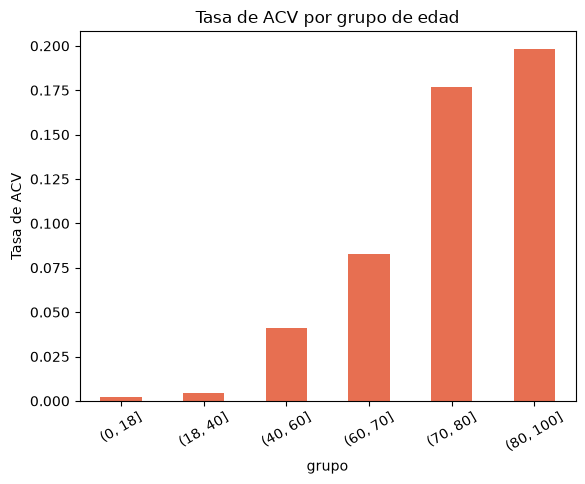

{'(0, 18]': 0.002, '(18, 40]': 0.005, '(40, 60]': 0.041, '(60, 70]': 0.082, '(70, 80]': 0.177, '(80, 100]': 0.198}
Edad mediana: sin ACV 43.0 | con ACV 71.0


In [7]:
OBJETIVO = "acv"
por_edad = df.assign(grupo=pd.cut(df["age"], [0, 18, 40, 60, 70, 80, 100])).groupby("grupo", observed=True)[OBJETIVO].apply(lambda s: (s == "Yes").mean())
por_edad.plot.bar(color="#e76f51")
plt.ylabel("Tasa de ACV")
plt.title("Tasa de ACV por grupo de edad")
plt.xticks(rotation=30)
plt.show()
print({str(k): round(float(v), 3) for k, v in por_edad.items()})
print("Edad mediana: sin ACV", df[df[OBJETIVO] == "No"]["age"].median(), "| con ACV", df[df[OBJETIVO] == "Yes"]["age"].median())

**La edad domina.** La tasa de ACV pasa de casi 0 en menores de 18 años a cerca del 20 % por encima de los 70.

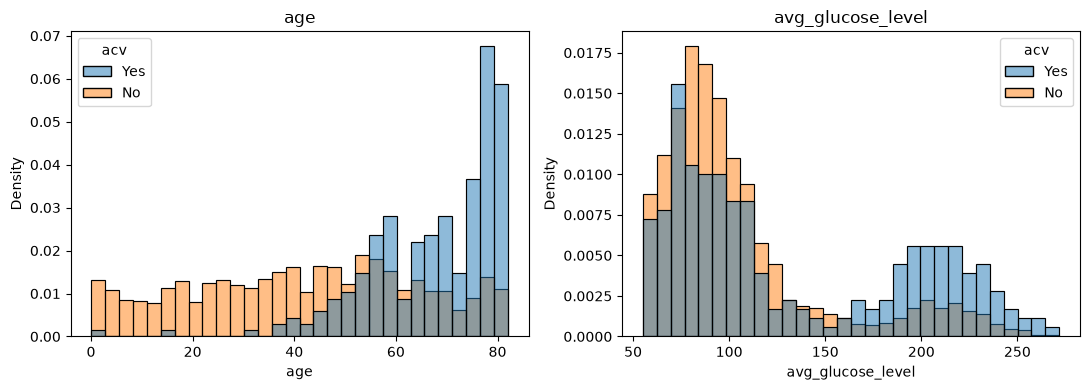

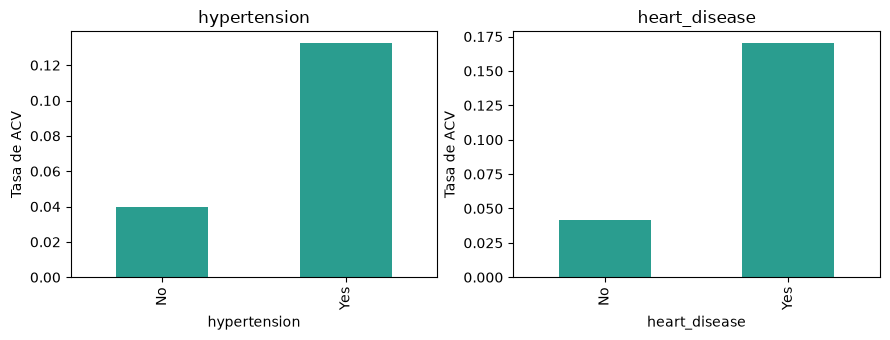

hypertension {'No': 0.04, 'Yes': 0.133}
heart_disease {'No': 0.042, 'Yes': 0.17}


In [8]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
for eje, columna in zip(ejes, ["age", "avg_glucose_level"]):
    sns.histplot(data=df, x=columna, hue=OBJETIVO, stat="density", common_norm=False, bins=30, ax=eje)
    eje.set_title(columna)
plt.tight_layout()
plt.show()

fig, ejes = plt.subplots(1, 2, figsize=(9, 3.5))
for eje, columna in zip(ejes, ["hypertension", "heart_disease"]):
    ((df[OBJETIVO] == "Yes").groupby(df[columna]).mean()).plot.bar(ax=eje, color="#2a9d8f")
    eje.set_ylabel("Tasa de ACV")
    eje.set_title(columna)
plt.tight_layout()
plt.show()
for columna in ["hypertension", "heart_disease"]:
    print(columna, ((df[OBJETIVO] == "Yes").groupby(df[columna]).mean()).round(3).to_dict())

La hipertensión y la enfermedad cardíaca multiplican la tasa de ACV varias veces. La glucosa es algo mayor en quienes tuvieron un ACV, pero con una diferencia pequeña frente a la edad.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

La división es estratificada: con solo 249 casos positivos, cada uno cuenta.

In [9]:
y = df[OBJETIVO]
train, test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=SEMILLA)
print("Entrenamiento:", len(train), "(%d con ACV)" % (y_train == "Yes").sum(), " Prueba:", len(test), "(%d con ACV)" % (y_test == "Yes").sum())

Entrenamiento: 4088 (199 con ACV)  Prueba: 1022 (50 con ACV)


### Qué variables aportan

Se prueban conjuntos de variables con regresión logística y validación cruzada (5 particiones por 4 repeticiones, solo con el entrenamiento), incluida la trampa del `bmi` faltante.

In [10]:
def armar(estimador, variables, escalar=True):
    numericas = [v for v in variables if v in ("age", "avg_glucose_level", "bmi", "bmi_faltante")]
    categoricas = [v for v in variables if v not in numericas]
    columnas = ColumnTransformer([
        ("num", Pipeline([("imputar", SimpleImputer(strategy="median"))] + ([("escala", StandardScaler())] if escalar else [])), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
    ])
    return Pipeline([("pre", columnas), ("modelo", estimador)])

NUMERICAS = ["age", "avg_glucose_level"]
VARIABLES = ["age", "avg_glucose_level", "hypertension", "heart_disease"]
TODAS = ["gender", "age", "hypertension", "heart_disease", "ever_married", "work_type", "residence_type", "avg_glucose_level", "bmi", "smoking_status"]
CONJUNTOS = {
    "10 (todas)": TODAS,
    "9 (sin género)": [c for c in TODAS if c != "gender"],
    "5 (las 4 elegidas + bmi imputado)": VARIABLES + ["bmi"],
    "4 (las elegidas, sin bmi)": VARIABLES,
    "1 (solo la edad)": ["age"],
    "4 + indicador de bmi faltante (artefacto, no se usa)": VARIABLES + ["bmi_faltante"],
}

validacion = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEMILLA)
filas = {}
for nombre, cols in CONJUNTOS.items():
    r = cross_validate(armar(LogisticRegression(max_iter=3000), cols), train[cols], y_train, cv=validacion, scoring="roc_auc")
    filas[nombre] = {"variables": len(cols), "AUC cv": r["test_score"].mean(), "desviación": r["test_score"].std()}
pd.DataFrame(filas).T.round(4).astype({"variables": int})

,variables,AUC cv,desviación
10 (todas),10,0.8374,0.0193
9 (sin género),9,0.8384,0.0187
5 (las 4 elegidas + bmi imputado),5,0.8418,0.0200
"4 (las elegidas, sin bmi)",4,0.8421,0.0202
1 (solo la edad),1,0.8341,0.0217
"4 + indicador de bmi faltante (artefacto, no se usa)",5,0.8550,0.0186


La **edad sola** ya alcanza casi lo mismo que todas las variables, y cuatro variables rinden igual o mejor que diez. Se adoptan las 4 variables clínicas: el formulario es corto y se evitan datos sensibles innecesarios.

El indicador de `bmi` faltante sube el AUC, pero es el artefacto de la recolección y **no se puede usar**.

### La trampa del bmi imputado

Si se imputa el `bmi` con la mediana, el valor imputado forma un pico que un árbol puede aislar. Veamos qué pasa con un Random Forest, con y sin `bmi`.

In [11]:
bosque = dict(n_estimators=200, min_samples_leaf=20, max_depth=6, random_state=SEMILLA, n_jobs=-1)
filas = {}
for nombre, cols in {"random forest sin bmi": VARIABLES, "random forest con bmi imputado por la mediana": VARIABLES + ["bmi"]}.items():
    r = cross_validate(armar(RandomForestClassifier(**bosque), cols, escalar=False), train[cols], y_train, cv=validacion, scoring="roc_auc")
    filas[nombre] = {"AUC cv": r["test_score"].mean(), "desviación": r["test_score"].std()}
pd.DataFrame(filas).T.round(4)

,AUC cv,desviación
random forest sin bmi,0.8347,0.0194
random forest con bmi imputado por la mediana,0.8455,0.0185


Con `bmi` el bosque sube, pero con la regresión logística agregar `bmi` no cambia nada (arriba: 0.8418 contra 0.8421). Todo el aporte medible del `bmi` es el artefacto: el árbol "descubre" que el valor imputado predice el ACV. Por eso el `bmi` **se excluye**.

> Analogía: es como un examen donde las hojas en blanco se corrigen siempre como reprobadas. Un alumno que aprende que "dejar la hoja en blanco" implica reprobar no aprendió nada de la materia.

### Candidatos

Se entrenan **sin pesos de clase**: la aplicación muestra una probabilidad, y los pesos la distorsionan (Van Calster et al., 2019). El desbalance se maneja con los umbrales.

In [12]:
def candidatos():
    return {
        "tasa base (línea base)": armar(DummyClassifier(strategy="prior"), VARIABLES),
        "regresión logística": armar(LogisticRegression(max_iter=3000), VARIABLES),
        "random forest": armar(RandomForestClassifier(**bosque), VARIABLES, escalar=False),
        "gradient boosting": armar(HistGradientBoostingClassifier(max_iter=120, learning_rate=0.05, max_depth=3, early_stopping=False, random_state=SEMILLA), VARIABLES, escalar=False),
    }

filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, train[VARIABLES], (y_train == "Yes").astype(int), cv=validacion, scoring={"auc": "roc_auc", "pr": "average_precision"}, error_score="raise")
    filas[nombre] = {"AUC ROC cv": r["test_auc"].mean(), "desviación": r["test_auc"].std(), "AUC PR cv": r["test_pr"].mean()}
comparacion = pd.DataFrame(filas).T.round(4)
comparacion

,AUC ROC cv,desviación,AUC PR cv
tasa base (línea base),0.5000,0.0000,0.0487
regresión logística,0.8421,0.0202,0.1887
random forest,0.8347,0.0194,0.1731
gradient boosting,0.8301,0.0212,0.1702


La regresión logística rinde igual o mejor que los modelos de árboles, con un modelo mucho más simple. Se elige.

In [13]:
ganador = comparacion.drop("tasa base (línea base)")["AUC ROC cv"].idxmax()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(train[VARIABLES], y_train)
coef = pd.Series(modelo.named_steps["modelo"].coef_[0], index=modelo.named_steps["pre"].get_feature_names_out()).round(2)
coef

Modelo elegido: regresión logística


num__age                  1.54
num__avg_glucose_level    0.18
cat__hypertension_No     -0.21
cat__hypertension_Yes     0.24
cat__heart_disease_No    -0.12
cat__heart_disease_Yes    0.14
dtype: float64

Con la edad estandarizada, su coeficiente es varias veces mayor que el de las demás variables: la edad domina el modelo.

### Dos umbrales

Con una clase tan rara, el umbral de 0.5 no detecta a nadie. Se calculan dos umbrales con predicciones **fuera de muestra del entrenamiento**:

- **Umbral F1:** maximiza el F1 de la clase positiva. Define el riesgo alto.
- **Umbral de sensibilidad:** el mayor umbral con el que se detecta al menos el 80 % de los casos. Es el criterio habitual de un tamizaje, en el que importa no dejar casos sin detectar.

In [14]:
y_bin_train = (y_train == "Yes").astype(int).to_numpy()
oof = cross_val_predict(candidatos()[ganador], train[VARIABLES], y_bin_train, method="predict_proba",
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))[:, 1]

def umbral_optimo_f1(y, p, rejilla=np.round(np.arange(0.01, 0.951, 0.01), 2)):
    puntajes = [f1_score(y, p >= t, zero_division=0) for t in rejilla]
    return round(float(rejilla[int(np.argmax(puntajes))]), 2)

def umbral_para_recall(y, p, objetivo=0.8, rejilla=np.round(np.arange(0.005, 0.951, 0.005), 3)):
    for umbral in sorted(rejilla, reverse=True):
        if (p[y == 1] >= umbral).mean() >= objetivo:
            return round(float(umbral), 3)
    return round(float(min(rejilla)), 3)

umbral = umbral_optimo_f1(y_bin_train, oof)
umbral_sens = umbral_para_recall(y_bin_train, oof)
print("Umbral F1:", umbral, "| umbral de sensibilidad (recall >= 0.8):", umbral_sens)

Umbral F1: 0.11 | umbral de sensibilidad (recall >= 0.8): 0.045


##### Evaluación en el conjunto de prueba

In [15]:
p_yes = modelo.predict_proba(test[VARIABLES])[:, 1]
y_bin = (y_test == "Yes").astype(int).to_numpy()
prevalencia = y_bin.mean()
print("AUC ROC: %.3f" % roc_auc_score(y_bin, p_yes))
print("AUC PR:  %.3f (azar = %.3f)" % (average_precision_score(y_bin, p_yes), prevalencia))
print("Brier:   %.4f (tasa base %.4f)" % (brier_score_loss(y_bin, p_yes), prevalencia * (1 - prevalencia)))

def al_umbral(t):
    pred = (p_yes >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, pred, labels=[0, 1]).ravel()
    return {"exactitud": (pred == y_bin).mean(), "precisión": precision_score(y_bin, pred, zero_division=0),
            "recall": recall_score(y_bin, pred), "F1": f1_score(y_bin, pred, zero_division=0), "TN": tn, "FP": fp, "FN": fn, "TP": tp}

pd.DataFrame({"umbral F1 (%s)" % umbral: al_umbral(umbral), "umbral de sensibilidad (%s)" % umbral_sens: al_umbral(umbral_sens),
              "umbral 0.5": al_umbral(0.5)}).T.round(3).astype({"TN": int, "FP": int, "FN": int, "TP": int})

AUC ROC: 0.840
AUC PR:  0.262 (azar = 0.049)
Brier:   0.0409 (tasa base 0.0465)


,exactitud,precisión,recall,F1,TN,FP,FN,TP
umbral F1 (0.11),0.861,0.205,0.64,0.311,848,124,18,32
umbral de sensibilidad (0.045),0.725,0.131,0.82,0.226,700,272,9,41
umbral 0.5,0.951,0.000,0.00,0.000,972,0,50,0


Con el umbral de 0.5 la exactitud es la misma que la de predecir siempre "No" (alrededor del 95 %) y no se detecta ningún caso. Con los otros dos umbrales se detecta una parte importante de los casos a costa de muchos falsos positivos, lo normal en un tamizaje de una condición rara.

### Intervalos de confianza

Con solo 50 casos positivos en la prueba las métricas son muy ruidosas. Se calculan intervalos del 95 % con bootstrap.

In [16]:
def intervalo_bootstrap(y, p, funcion, remuestreos=1000, semilla=42):
    rng = np.random.default_rng(semilla)
    valores = []
    while len(valores) < remuestreos:
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            valores.append(funcion(y[i], p[i]))
    return [round(float(np.percentile(valores, 2.5)), 4), round(float(np.percentile(valores, 97.5)), 4)]

recall_en = lambda u: (lambda y, p: float((p[y == 1] >= u).mean()))
pd.DataFrame({"IC 95 %": {"AUC ROC": intervalo_bootstrap(y_bin, p_yes, roc_auc_score),
                           "AUC PR": intervalo_bootstrap(y_bin, p_yes, average_precision_score),
                           "recall al umbral F1": intervalo_bootstrap(y_bin, p_yes, recall_en(umbral)),
                           "recall al umbral de sensibilidad": intervalo_bootstrap(y_bin, p_yes, recall_en(umbral_sens))}})

,IC 95 %
AUC ROC,"[0.7798, 0.8952]"
AUC PR,"[0.1737, 0.3701]"
recall al umbral F1,"[0.5, 0.7692]"
recall al umbral de sensibilidad,"[0.7083, 0.9259]"


Los intervalos son amplios: con tan pocos casos, cada métrica podría ser bastante mejor o peor con otra muestra. No hay que leer las cifras como exactas.

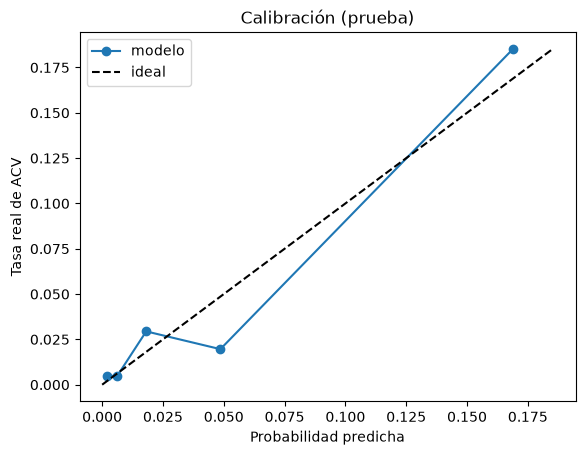

In [17]:
frac, media = calibration_curve(y_bin, p_yes, n_bins=5, strategy="quantile")
plt.plot(media, frac, "o-", label="modelo")
plt.plot([0, max(media.max(), frac.max())], [0, max(media.max(), frac.max())], "k--", label="ideal")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Tasa real de ACV")
plt.title("Calibración (prueba)")
plt.legend()
plt.show()

### Predicción para un paciente nuevo

In [18]:
paciente = pd.DataFrame([{"age": 67, "avg_glucose_level": 105.0, "hypertension": "Yes", "heart_disease": "No"}])
p = modelo.predict_proba(paciente[VARIABLES])[0, 1]
nivel = "alto" if p >= umbral else "moderado" if p >= umbral_sens else "bajo"
print("Probabilidad estimada: %.1f %%  ->  riesgo %s" % (100 * p, nivel))

Probabilidad estimada: 12.0 %  ->  riesgo alto


---
# Conclusiones
---

## Resultados

Con cuatro datos clínicos básicos (edad, hipertensión, enfermedad cardíaca y glucosa) el modelo distingue a los pacientes con ACV con un AUC cercano a 0.84, frente a 0.5 de la línea base. La edad sola ya explica casi todo.

Hay dos hallazgos metodológicos importantes. El primero es que el `bmi` faltante predice el ACV, pero es un artefacto de la recolección y se descartó, porque un modelo flexible lo habría aprendido sin que se note. El segundo es que con 50 casos positivos en la prueba los intervalos de confianza son muy amplios.

Limitaciones: el origen del conjunto es confidencial y se desconoce cómo se definió el ACV. Las probabilidades son bajas y los falsos positivos son frecuentes a cualquier umbral útil. **No es una herramienta de diagnóstico.**

### Referencias

> Boehme, A. K., Esenwa, C., & Elkind, M. S. V. (2017). Stroke risk factors, genetics, and prevention. *Circulation Research*, 120(3), 472-495.
> Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). Wiley.
> Soriano, F. (2021). *Stroke Prediction Dataset*. Kaggle.
> Van Calster, B., McLernon, D. J., van Smeden, M., Wynants, L., & Steyerberg, E. W. (2019). Calibration: the Achilles heel of predictive analytics. *BMC Medicine*, 17, 230.